In [2]:
import os
import sys
import re
import pandas as pd

# Add project root to Python path
from pathlib import Path
project_root = Path.cwd().parent  # Go up one level from src to project root
sys.path.append(str(project_root))
from config.const import DEFAULT_TARGET_FEATURE

# === DON'T RUN THIS IF YOU ALREADY HAVE YEARLY DATA ===

def merge_monthly_to_yearly(preprocessed_dir, output_dir):
    # List all files matching the pattern for months 01-12
    files = [f for f in os.listdir(preprocessed_dir) if re.match(r'preprocessed_data_2018-2024_\d{2}\.csv', f)]
    files = sorted(files, key=lambda x: int(re.search(r'_(\d{2})\.csv', x).group(1)))  # sort by month

    # Dictionary to collect dataframes for each year
    year_data = {}

    for f in files:
        month = int(re.search(r'_(\d{2})\.csv', f).group(1))
        df = pd.read_csv(os.path.join(preprocessed_dir, f))
        for year in df['data_year'].unique():
            year_df = df[df['data_year'] == year].copy()
            year_df['month'] = month
            if year not in year_data:
                year_data[year] = []
            year_data[year].append(year_df)

    # Concatenate and save for each year
    for year, dfs in year_data.items():
        merged_df = pd.concat(dfs, ignore_index=True)
        output_fname = f'preprocessed_data_{year}.csv'
        output_path = os.path.join(output_dir, output_fname)
        merged_df.to_csv(output_path, index=False)
        print(f"Saved {output_path} with {len(merged_df)} rows.")

print(f"DEFAULT_TARGET_FEATURE: '{DEFAULT_TARGET_FEATURE}'")

if DEFAULT_TARGET_FEATURE == 'differenceInMinutes_eachStation_offset': 
    preprocessed_dir = os.path.join('..', 'data', 'output', 'preprocessed', 'differenceInMinutes_eachStation_offset')
    output_dir = os.path.join('..', 'data', 'output', 'yearly_dataset', 'differenceInMinutes_eachStation_offset')
    merge_monthly_to_yearly(preprocessed_dir, output_dir)
else: 
    preprocessed_dir = os.path.join('..', 'data', 'output', 'preprocessed', 'differenceInMinutes')
    output_dir = os.path.join('..', 'data', 'output', 'yearly_dataset', 'differenceInMinutes') 
    merge_monthly_to_yearly(preprocessed_dir, output_dir)


DEFAULT_TARGET_FEATURE: 'differenceInMinutes'
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2018.csv with 396356 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2019.csv with 384397 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2020.csv with 386443 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2021.csv with 511615 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2022.csv with 500593 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2023.csv with 503040 rows.
Saved ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2024.csv with 668744 rows.


In [24]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

# --- Configuration ---
# target_column = 'differenceInMinutes_eachStation_offset'
target_column = 'differenceInMinutes'

data_directory = os.path.join('..', 'data', 'output', 'yearly_dataset', target_column) 

# --- Step 1: Load and Consolidate Data ---
print("--- Step 1: Loading and Consolidating Data ---")
pattern = os.path.join(data_directory, 'preprocessed_data_*.csv') 
yearly_files = sorted(glob.glob(pattern))

if not yearly_files:
    print(f"ERROR: No CSV files found in {data_directory} with pattern 'preprocessed_data_*.csv'. Please check path and file names.")
    exit()

df_list = []
for f in yearly_files:
    print(f"Loading {f}...")
    df_list.append(pd.read_csv(f))

df_full = pd.concat(df_list, ignore_index=True)

# Ensure 'scheduledTime' is a proper datetime object and sort
df_full['scheduledTime'] = pd.to_datetime(df_full['scheduledTime']).dt.tz_localize(None)
df_full = df_full.sort_values(by='scheduledTime').reset_index(drop=True)

print(f"Combined data shape: {df_full.shape}")
df_full.head()

--- Step 1: Loading and Consolidating Data ---
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2018.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2019.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2020.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2021.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2022.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2023.csv...
Loading ..\data\output\yearly_dataset\differenceInMinutes\preprocessed_data_2024.csv...
Combined data shape: (3351188, 16)


,differenceInMinutes,stationName,scheduledTime,Air temperature,Wind speed,Gust speed,Wind direction,Relative humidity,Dew-point temperature,Precipitation intensity,Snow depth,Pressure (msl),Horizontal visibility,Cloud amount,data_year,month
0,1.0,Rovaniemi,2018-01-01 07:05:00,-2.9,1.9,3.0,125.0,88.0,-4.7,0.0,57.0,999.5,38460.0,8.0,2018,1
1,1.0,Muurola,2018-01-01 07:21:00,-2.8,2.0,4.1,126.0,87.0,-4.7,0.0,57.0,999.4,34780.0,8.0,2018,1
2,12.0,Muurola,2018-01-01 07:24:00,-2.8,2.0,4.1,126.0,87.0,-4.7,0.0,57.0,999.4,34780.0,8.0,2018,1
3,13.0,Koivu,2018-01-01 07:39:00,-2.8,1.8,3.2,127.0,88.0,-4.6,0.0,60.0,999.4,33500.0,8.0,2018,1
4,13.0,Koivu,2018-01-01 07:39:00,-2.8,1.8,3.2,127.0,88.0,-4.6,0.0,60.0,999.4,33500.0,8.0,2018,1


In [25]:
# --- Step 3: Target Variable Distribution ---
print("--- Step 3: Target Variable Distribution ---")
print(f"\nDescriptive Statistics for '{target_column}':")
print(df_full[target_column].describe())

# # Histogram/KDE plot
# plt.figure(figsize=(10, 6))
# sns.histplot(df_full[target_column], bins=50, kde=True)
# plt.title(f'Distribution of {target_column}')
# plt.xlabel('Delay in Minutes')
# plt.ylabel('Frequency')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

# # Box Plot to visualize outliers
# plt.figure(figsize=(10, 6))
# sns.boxplot(y=df_full[target_column])
# plt.title(f'Box Plot of {target_column}')
# plt.ylabel('Delay in Minutes')
# plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

# Imbalance Check: Proportion of zero/negative/small vs. large delays
zero_delays = (df_full[target_column] == 0).sum()
negative_delays = (df_full[target_column] < 0).sum()
small_positive_delays = ((df_full[target_column] > 0) & (df_full[target_column] <= 5)).sum() # e.g., < 5 mins
significant_delays = (df_full[target_column] > 5).sum() # e.g., > 5 mins

total_records = len(df_full)

print(f"\nTarget Variable Imbalance:")
print(f"Total records: {total_records}")
print(f"Records with exactly 0 minutes delay: {zero_delays} ({zero_delays/total_records:.2%})")
print(f"Records with negative delay (early): {negative_delays} ({negative_delays/total_records:.2%})")
print(f"Records with small positive delay (0-5 mins): {small_positive_delays} ({small_positive_delays/total_records:.2%})")
print(f"Records with significant delay (>5 mins): {significant_delays} ({significant_delays/total_records:.2%})")

print("\n" + "="*50 + "\n")


--- Step 3: Target Variable Distribution ---

Descriptive Statistics for 'differenceInMinutes':
count    3.351188e+06
mean     6.232740e+00
std      2.345560e+01
min     -6.950000e+02
25%      0.000000e+00
50%      2.000000e+00
75%      6.000000e+00
max      9.740000e+02
Name: differenceInMinutes, dtype: float64

Target Variable Imbalance:
Total records: 3351188
Records with exactly 0 minutes delay: 401399 (11.98%)
Records with negative delay (early): 766256 (22.87%)
Records with small positive delay (0-5 mins): 1302031 (38.85%)
Records with significant delay (>5 mins): 881502 (26.30%)




--- Step 4: Feature Distributions ---


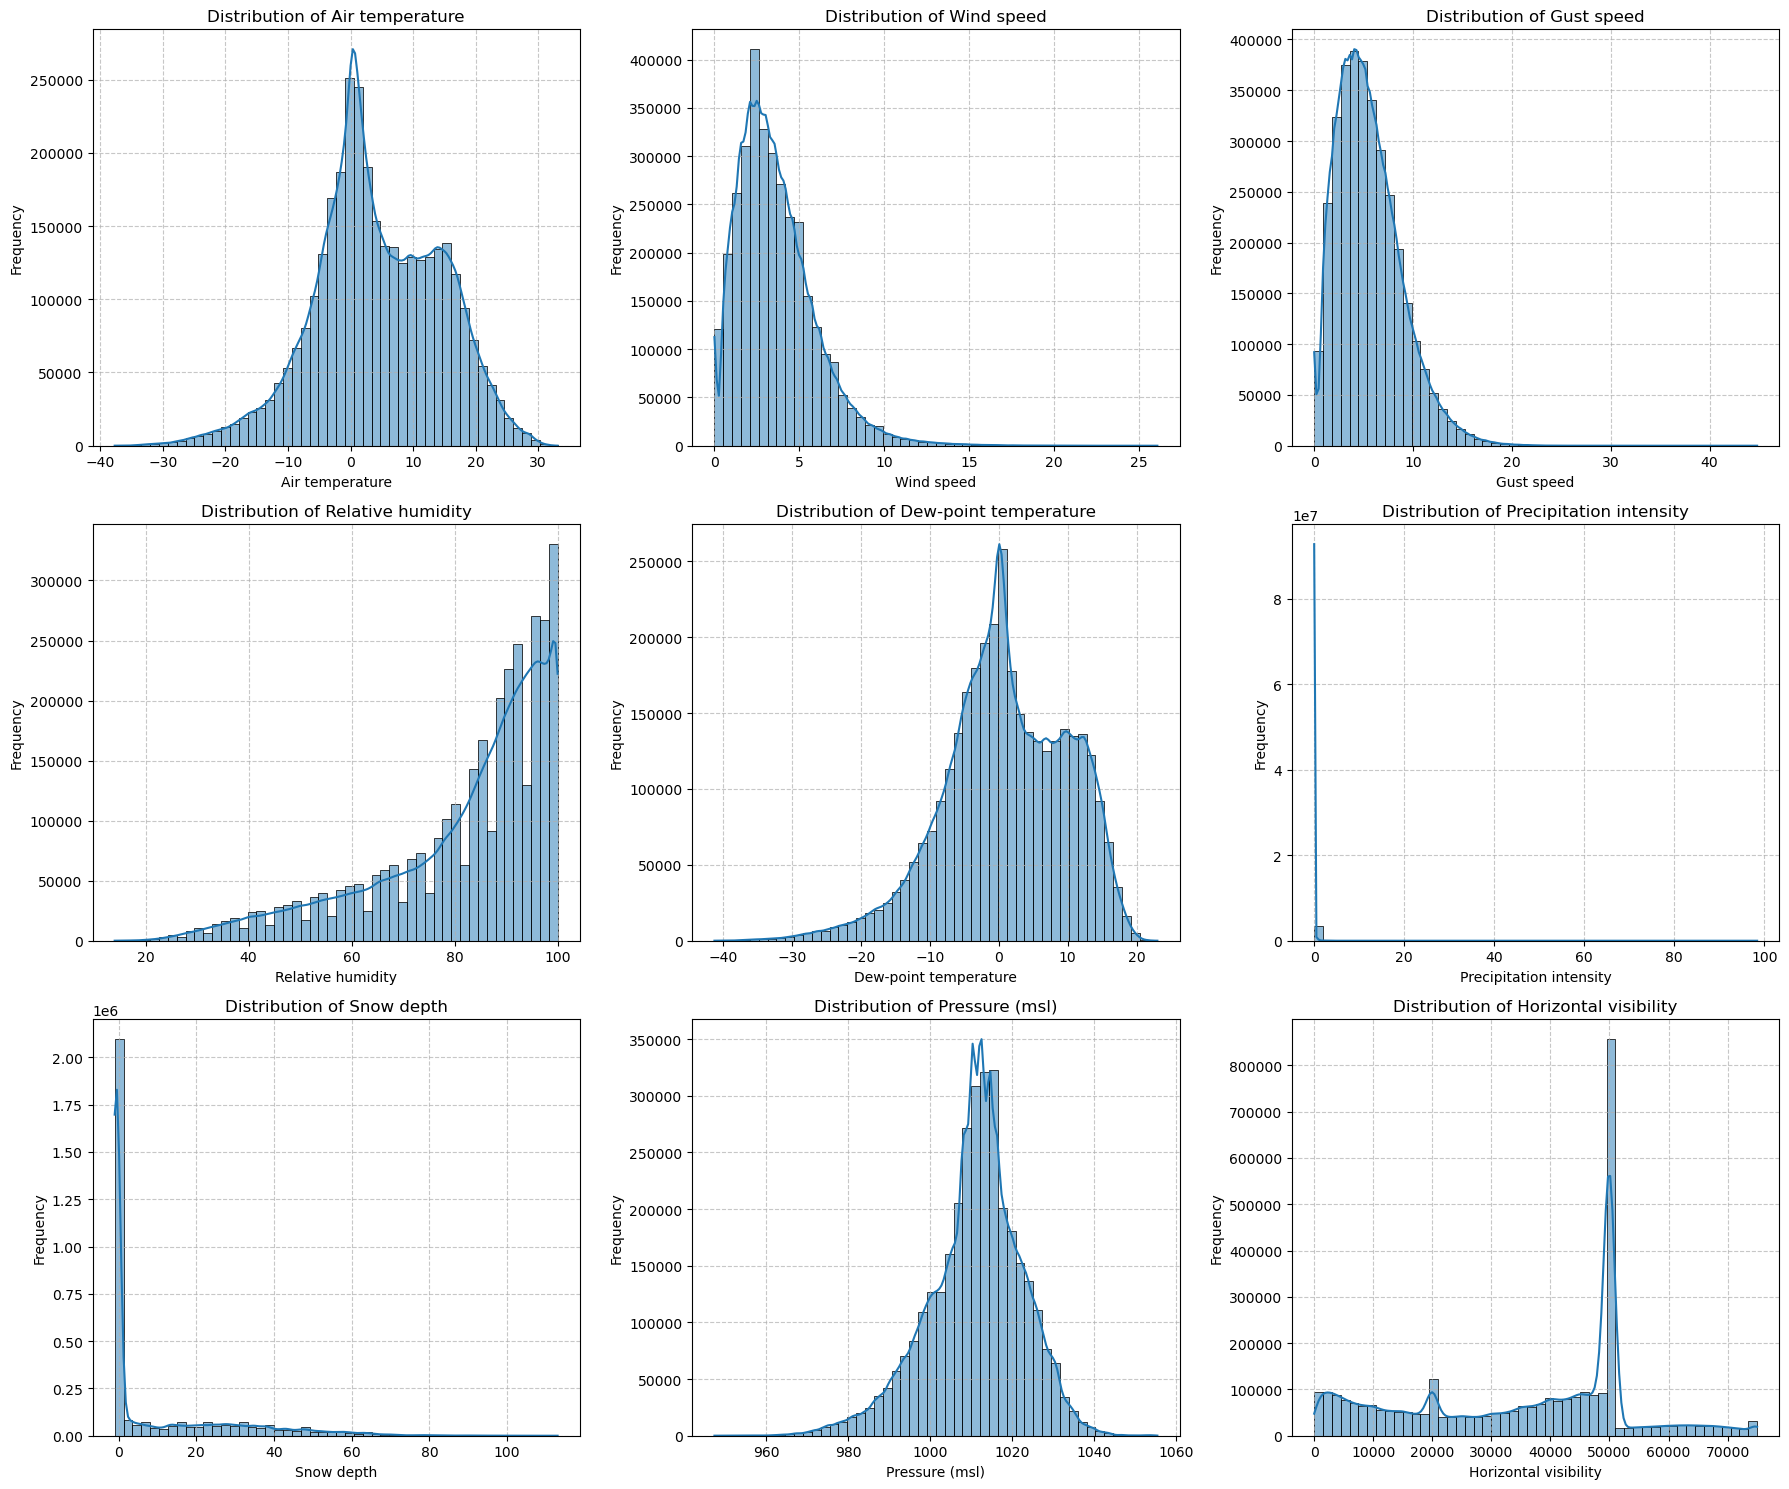

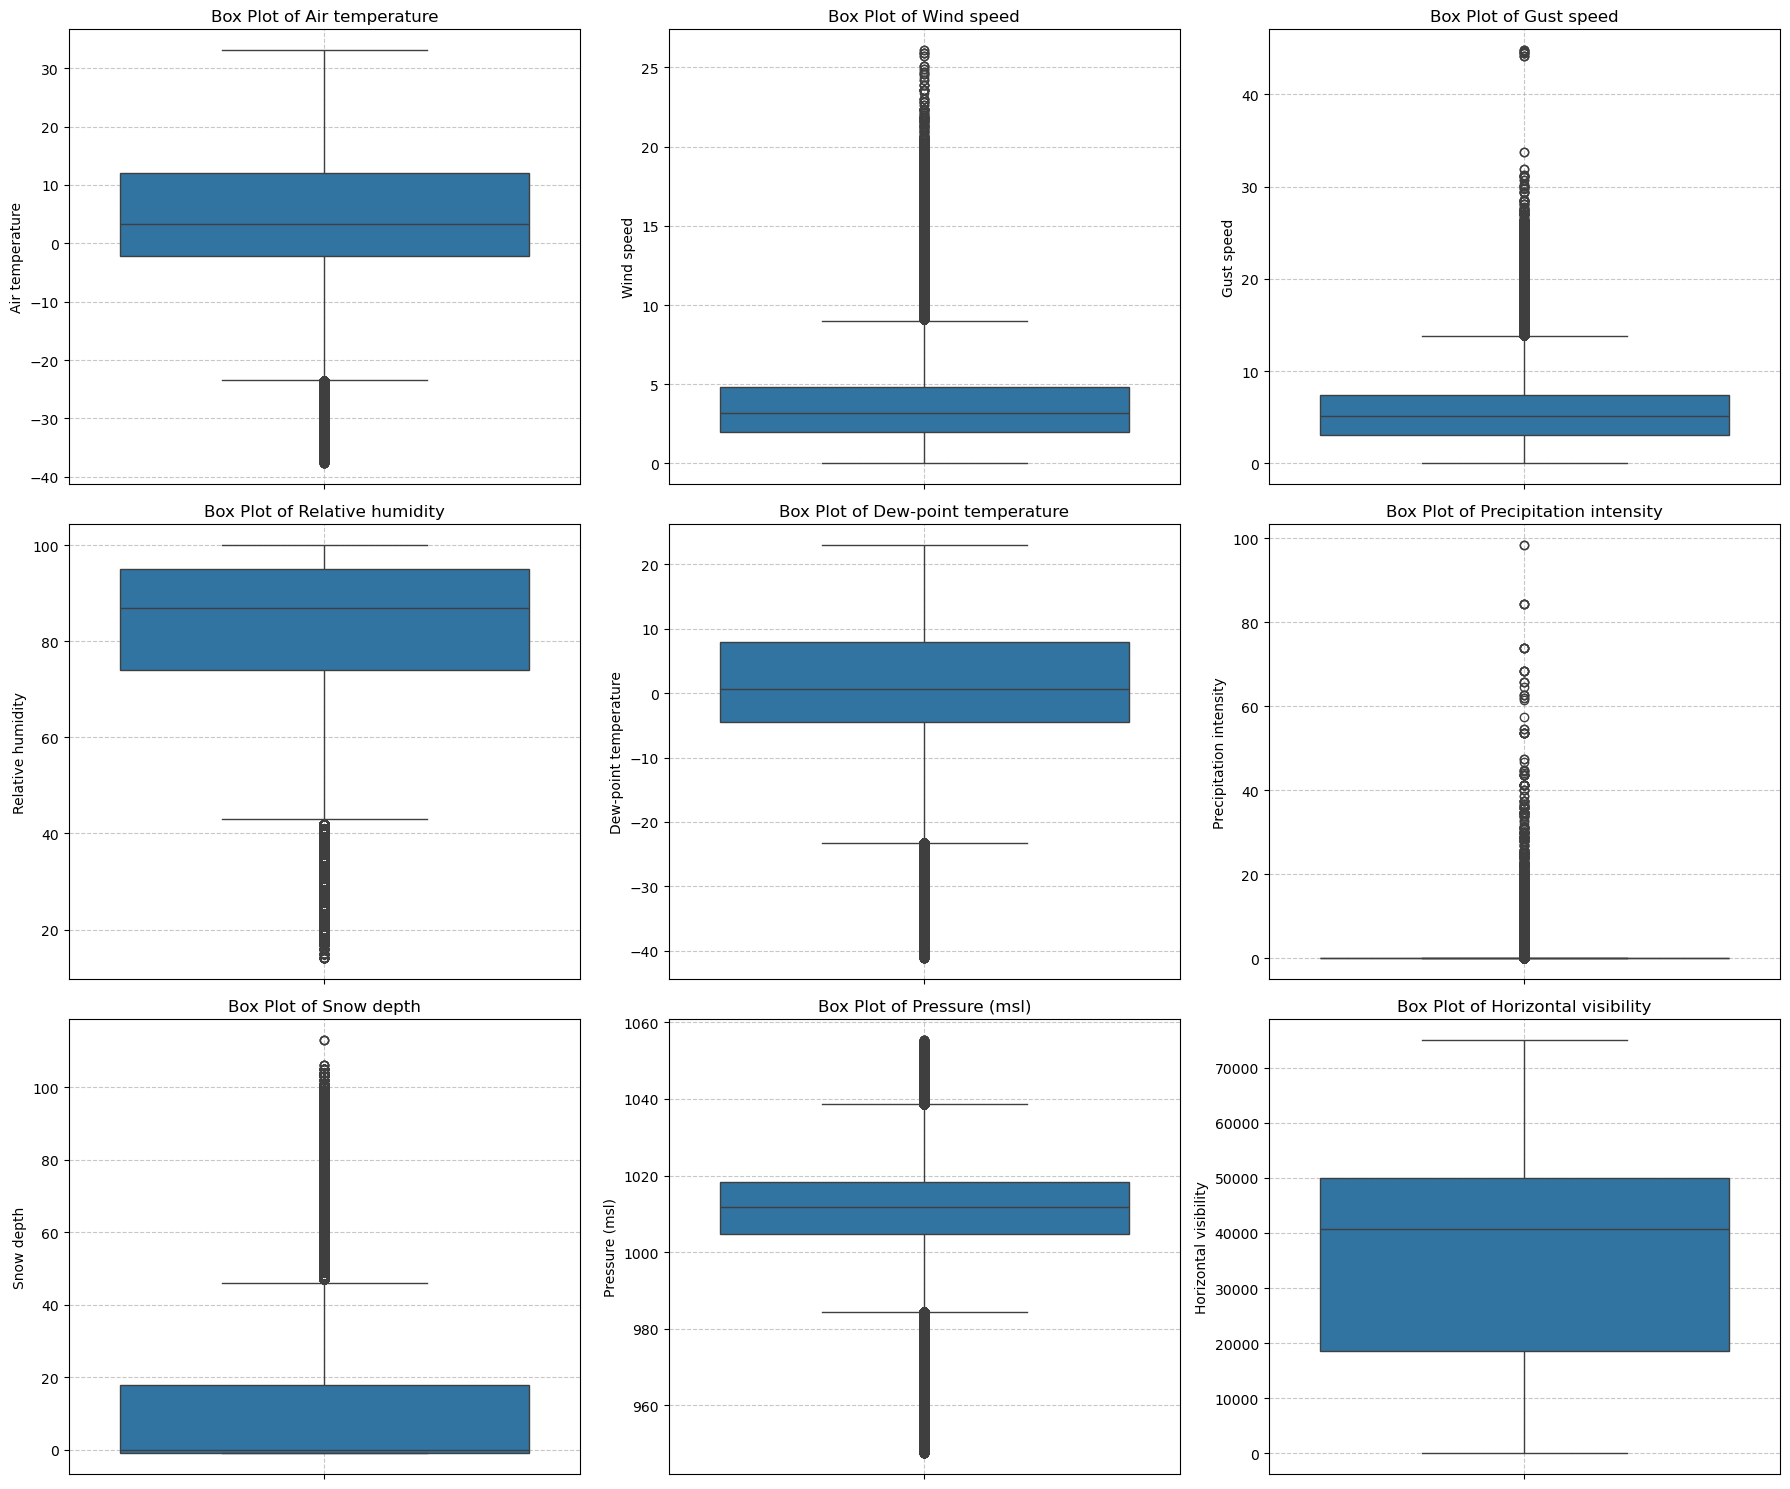

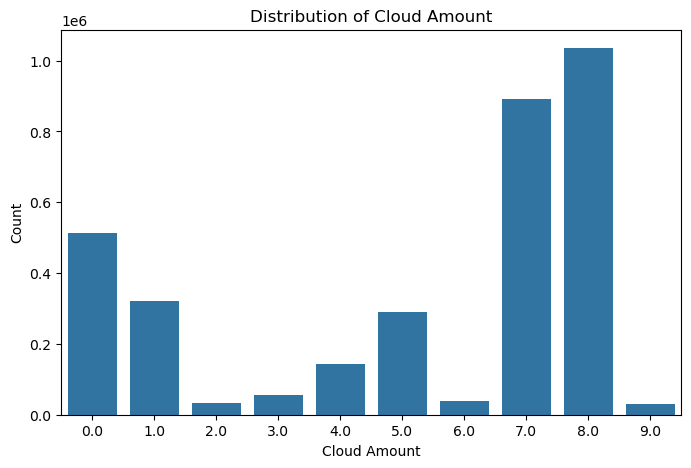

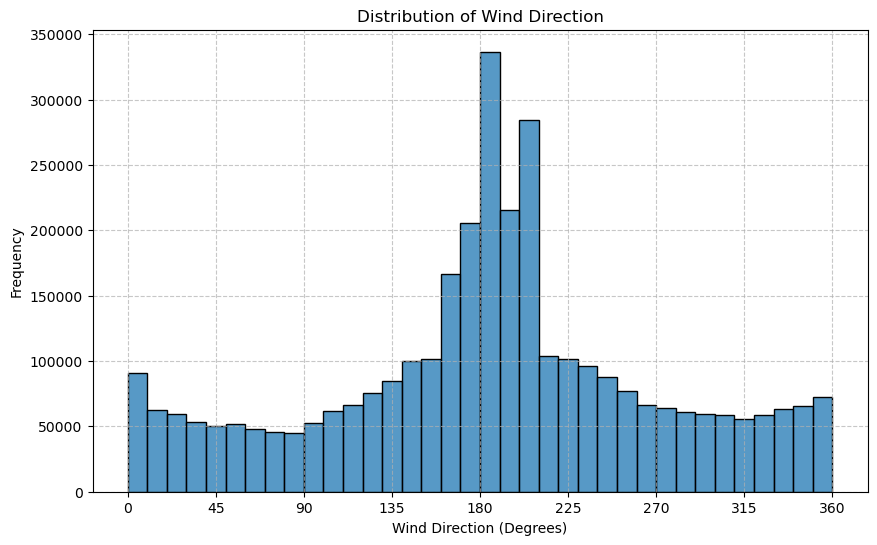

In [26]:
# --- Step 4: Feature Distributions (Weather Variables and Key Categoricals) ---
print("--- Step 4: Feature Distributions ---")

# Numerical Weather Features
numerical_weather_features = [
    'Air temperature', 'Wind speed', 'Gust speed', 'Relative humidity',
    'Dew-point temperature', 'Precipitation intensity', 'Snow depth',
    'Pressure (msl)', 'Horizontal visibility'
]

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_weather_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df_full[col], bins=50, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Box plots for numerical weather features to check for outliers
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_weather_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df_full[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Categorical/Discrete Features
categorical_features = ['stationName', 'Cloud amount'] # Wind direction also, but often better as sin/cos

# Cloud amount distribution
plt.figure(figsize=(8, 5))
sns.countplot(x=df_full['Cloud amount'])
plt.title('Distribution of Cloud Amount')
plt.xlabel('Cloud Amount')
plt.ylabel('Count')
plt.show()

# Wind direction (as a discrete histogram, though sin/cos is better for modeling)
plt.figure(figsize=(10, 6))
sns.histplot(df_full['Wind direction'], bins=36, kde=False) # 36 bins for 10-degree intervals
plt.title('Distribution of Wind Direction')
plt.xlabel('Wind Direction (Degrees)')
plt.ylabel('Frequency')
plt.xticks(np.arange(0, 361, 45))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\n" + "="*50 + "\n")

--- Step 5: Correlation Analysis ---


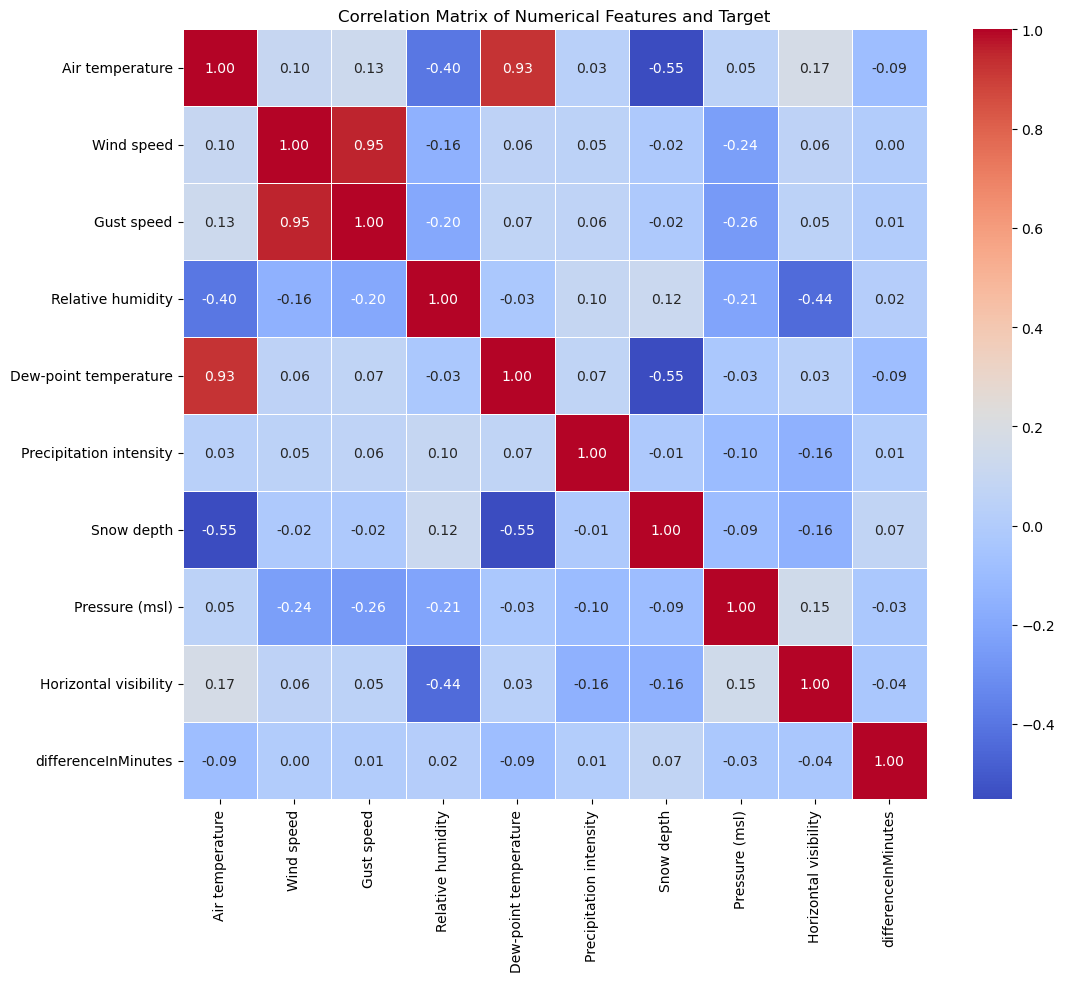


Correlations with 'differenceInMinutes':
differenceInMinutes        1.000000
Snow depth                 0.074440
Relative humidity          0.017387
Precipitation intensity    0.006332
Gust speed                 0.005765
Wind speed                 0.004245
Pressure (msl)            -0.028185
Horizontal visibility     -0.035261
Air temperature           -0.087341
Dew-point temperature     -0.088312
Name: differenceInMinutes, dtype: float64




In [27]:
# --- Step 5: Correlation Analysis (for numerical features and target) ---
print("--- Step 5: Correlation Analysis ---")

# Select only numerical columns for correlation matrix, including the target
numerical_cols_for_corr = numerical_weather_features + [target_column]

corr_matrix = df_full[numerical_cols_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features and Target')
plt.show()

print(f"\nCorrelations with '{target_column}':")
print(corr_matrix[target_column].sort_values(ascending=False))
print("\n" + "="*50 + "\n")


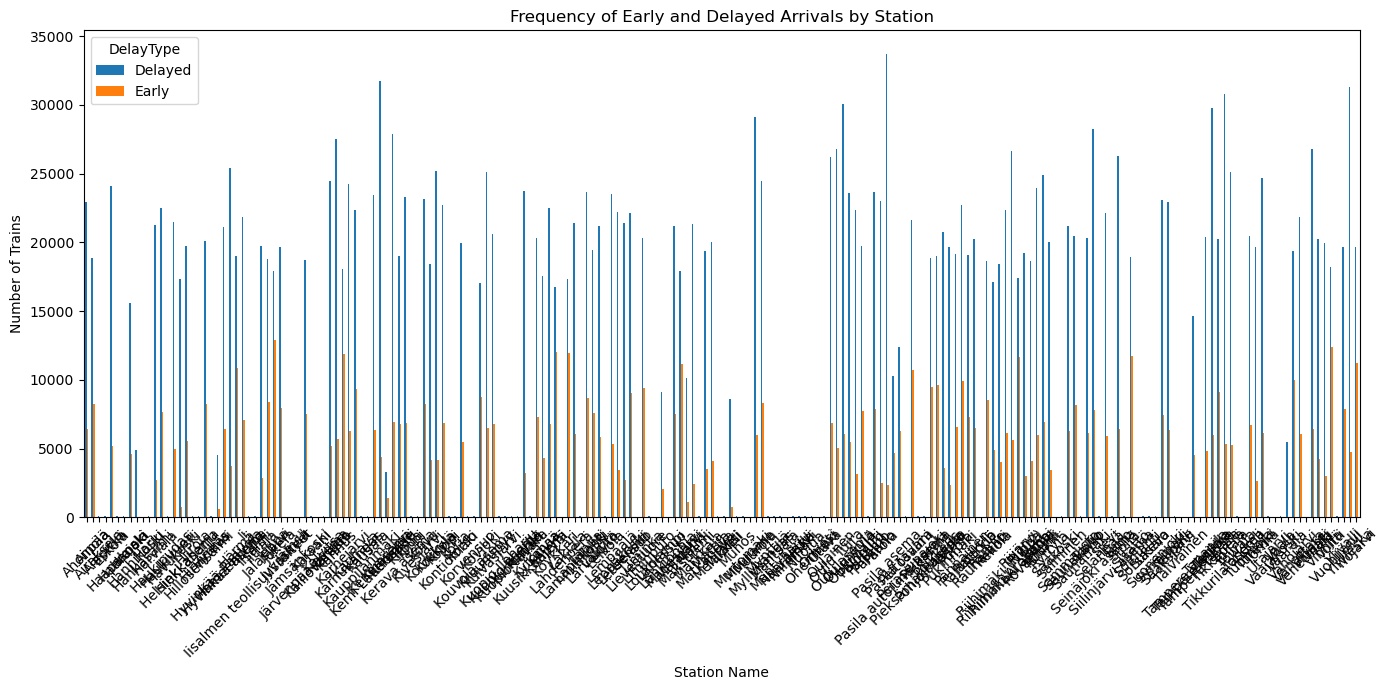

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Example: target_column = 'delay_minutes'
# If target_column is a list, use target_column[0]
delay_col = target_column if isinstance(target_column, str) else target_column[0]

# Create a new column to classify delay type
df_full['DelayType'] = df_full[delay_col].apply(lambda x: 'Early' if x < 0 else 'Delayed')

# Count frequency of each delay type per station
delay_freq = df_full.groupby(['stationName', 'DelayType']).size().unstack(fill_value=0)

# Plot
delay_freq.plot(kind='bar', stacked=False, figsize=(14, 7))
plt.xlabel('Station Name')
plt.ylabel('Number of Trains')
plt.title('Frequency of Early and Delayed Arrivals by Station')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ... (previous code to compute delay_freq)

# Reset index so 'stationName' becomes a column
delay_freq_reset = delay_freq.reset_index()

# Rename columns for clarity
delay_freq_reset.columns.name = None
delay_freq_reset = delay_freq_reset.rename_axis(None, axis=1)
delay_freq_reset = delay_freq_reset.rename(columns={'Early': 'Early', 'Delayed': 'Delayed', 'stationName': 'Station Name'})

# Save to text file in table format
with open('delay_frequencies.txt', 'w') as f:
    f.write(delay_freq_reset.to_string(index=False))

In [28]:
# def categorize_delay(minutes):
#     if minutes < 0:
#         return 'early_arrival'
#     elif minutes == 0:
#         return 'on_time'
#     elif 1 <= minutes <= 5: # This covers 1, 2, 3, 4, 5 minutes
#         return 'delayed_1_5_mins'
#     else: # minutes > 5 (This covers all delays greater than 5 minutes)
#         return 'delay_gt_5'
    
# def categorize_delay(minutes):
#     if  -50 < minutes <= 0:
#         return 'early_on_time'
#     elif 1 <= minutes <= 5: # This covers 1, 2, 3, 4, 5 minutes
#         return 'delayed_1_5_mins'
#     elif 5 < minutes <= 50: # minutes > 5 (This covers all delays greater than 5 minutes)
#         return 'delay_gt_5'
    
def categorize_delay(minutes):
    if  minutes <= 0:
        return 'early_on_time'
    elif 1 <= minutes <= 5: # This covers 1, 2, 3, 4, 5 minutes
        return 'delayed_1_5_mins'
    else: # minutes > 5 (This covers all delays greater than 5 minutes)
        return 'delay_gt_5'

df_full['delay_class'] = df_full[target_column].apply(categorize_delay)

# # Drop rows where delay_class is missing (None or NaN)
# df_full = df_full[df_full['delay_class'].notna()]

print("New Delay Class Distribution:")
print(df_full['delay_class'].value_counts())


New Delay Class Distribution:
delay_class
delayed_1_5_mins    1302031
early_on_time       1167655
delay_gt_5           881502
Name: count, dtype: int64


C:\Users\usama\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


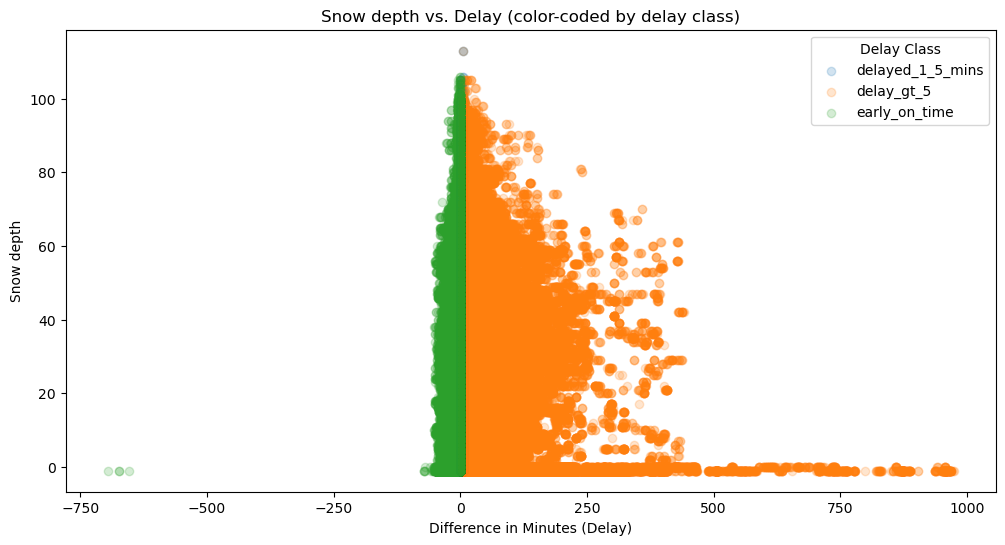

In [29]:
import matplotlib.pyplot as plt

# Choose your weather feature, e.g., 'Snow depth'

# numerical_weather_features = [
#     'Air temperature', 'Wind speed', 'Gust speed', 'Relative humidity',
#     'Dew-point temperature', 'Precipitation intensity', 'Snow depth',
#     'Pressure (msl)', 'Horizontal visibility'
# ]

feature = 'Snow depth'

plt.figure(figsize=(12,6))
for label in df_full['delay_class'].unique():
    mask = df_full['delay_class'] == label
    plt.scatter(df_full.loc[mask, target_column], df_full.loc[mask, feature], label=label, alpha=0.2)
plt.xlabel('Difference in Minutes (Delay)')
plt.ylabel(feature)
plt.title(f'{feature} vs. Delay (color-coded by delay class)')
plt.legend(title='Delay Class')
plt.show()

In [30]:
variance_by_class = df_full.groupby('delay_class')[target_column].var()
print(variance_by_class)

delay_class
delay_gt_5          1607.149664
delayed_1_5_mins       1.773473
early_on_time         23.729239
Name: differenceInMinutes, dtype: float64


C:\Users\usama\AppData\Local\Temp\ipykernel_22636\3015898370.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


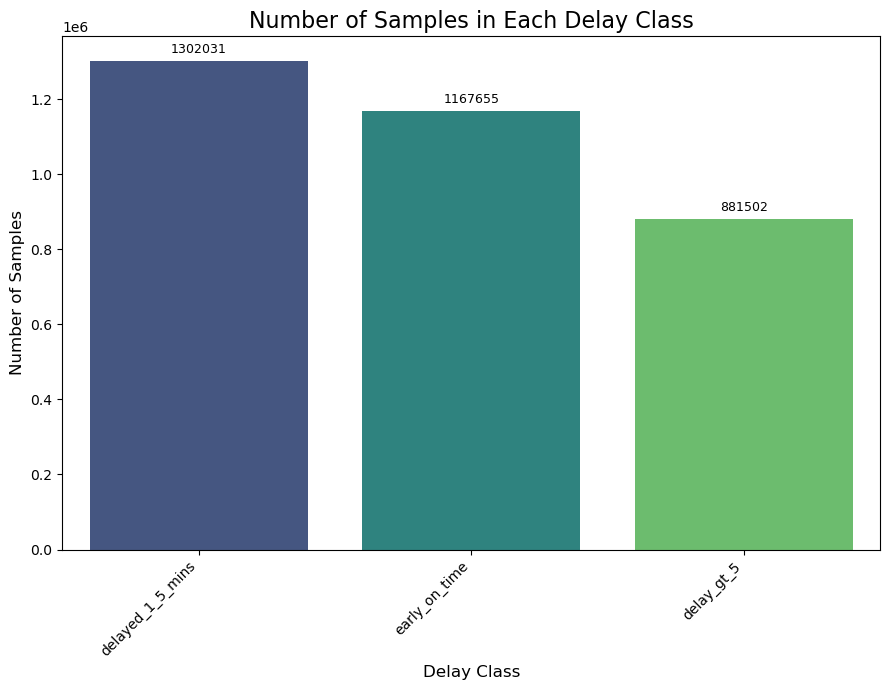

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Step 2: Plotting code adjusted for new labels ---

# Calculate the value counts for each delay class
class_counts = df_full['delay_class'].value_counts()

# Create the bar plot for counts
plt.figure(figsize=(9, 7)) # Adjust figure size as needed
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# Add labels and title
plt.title('Number of Samples in Each Delay Class', fontsize=16)
plt.xlabel('Delay Class', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate x-axis labels for readability
plt.yticks(fontsize=10)

# Add the count on top of each bar for better readability
for index, value in enumerate(class_counts.values):
    # Position text slightly above bar, adjusting for scale
    plt.text(index, value + (class_counts.max() * 0.01),
             f'{value}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [32]:
count_over_60 = ((df_full[target_column] > -30) & (df_full[target_column] <= 60)).sum()
print(f"Number of rows with differenceInMinutes > 60: {count_over_60}")

Number of rows with differenceInMinutes > 60: 3280309


In [33]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier # Or XGBClassifier, LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_full with 'delay_class' is already created

# New target for classification
target_column_classification = 'delay_class'

# Features (same as before, excluding original target and time-related columns for direct use)
initial_features_for_classification = [
    # 'stationName', 
    # 'Cloud amount'
    'Air temperature', 
    'Wind speed',
    'Gust speed',
    'Wind direction',
    'Relative humidity',
    'Dew-point temperature',
    # 'Precipitation intensity',
    'Snow depth', 
    'Pressure (msl)',
    'Horizontal visibility'
]

# Extract features (X) and the NEW classification target (y_clf)
X_all = df_full[initial_features_for_classification].copy()
y_all_clf = df_full[target_column_classification].copy()

# Re-establish train/test split based on scheduledTime, now including y_all_clf
train_cutoff_date = pd.to_datetime('2023-12-31 23:59:59') 

train_indices = df_full['scheduledTime'] <= train_cutoff_date
test_indices = df_full['scheduledTime'] > train_cutoff_date

X_train_raw = X_all[train_indices].copy()
y_train_clf = y_all_clf[train_indices].copy() # New classification target for training

X_test_raw = X_all[test_indices].copy()
y_test_clf = y_all_clf[test_indices].copy() # New classification target for testing

# Keep datetime series for feature engineering
train_datetime_series = df_full.loc[train_indices, 'scheduledTime'].copy()
test_datetime_series = df_full.loc[test_indices, 'scheduledTime'].copy()

print(f"Classification Training set shape: {X_train_raw.shape}, {y_train_clf.shape}")
print(f"Classification Test set shape: {X_test_raw.shape}, {y_test_clf.shape}")

Classification Training set shape: (2681930, 9), (2681930,)
Classification Test set shape: (669258, 9), (669258,)


In [34]:
# --- Step 3: Feature Engineering ---
print("\n--- Step 3: Feature Engineering ---")

# Create copies for processing. These will be modified with new features.
X_train_processed = X_train_raw.copy()
X_test_processed = X_test_raw.copy()

# --- Temporal Features from scheduledTime ---
# Extract components (ensure dt access works on datetime series)
X_train_processed['hour'] = train_datetime_series.dt.hour
X_train_processed['day_of_week'] = train_datetime_series.dt.dayofweek # Monday=0, Sunday=6
X_train_processed['month'] = train_datetime_series.dt.month
X_train_processed['day_of_year'] = train_datetime_series.dt.dayofyear # 1-366

X_test_processed['hour'] = test_datetime_series.dt.hour
X_test_processed['day_of_week'] = test_datetime_series.dt.dayofweek
X_test_processed['month'] = test_datetime_series.dt.month
X_test_processed['day_of_year'] = test_datetime_series.dt.dayofyear

# Sin/Cos transformations for cyclical temporal features
X_train_processed['hour_sin'] = np.sin(2 * np.pi * X_train_processed['hour'] / 24)
X_train_processed['hour_cos'] = np.cos(2 * np.pi * X_train_processed['hour'] / 24)
X_train_processed['month_sin'] = np.sin(2 * np.pi * X_train_processed['month'] / 12)
X_train_processed['month_cos'] = np.cos(2 * np.pi * X_train_processed['month'] / 12)
X_train_processed['day_of_year_sin'] = np.sin(2 * np.pi * X_train_processed['day_of_year'] / 365.25)
X_train_processed['day_of_year_cos'] = np.cos(2 * np.pi * X_train_processed['day_of_year'] / 365.25)

X_test_processed['hour_sin'] = np.sin(2 * np.pi * X_test_processed['hour'] / 24)
X_test_processed['hour_cos'] = np.cos(2 * np.pi * X_test_processed['hour'] / 24)
X_test_processed['month_sin'] = np.sin(2 * np.pi * X_test_processed['month'] / 12)
X_test_processed['month_cos'] = np.cos(2 * np.pi * X_test_processed['month'] / 12)
X_test_processed['day_of_year_sin'] = np.sin(2 * np.pi * X_test_processed['day_of_year'] / 365.25)
X_test_processed['day_of_year_cos'] = np.cos(2 * np.pi * X_test_processed['day_of_year'] / 365.25)

# Drop original hour, month, day_of_year columns as their info is now in sin/cos
X_train_processed = X_train_processed.drop(['hour', 'month', 'day_of_year'], axis=1)
X_test_processed = X_test_processed.drop(['hour', 'month', 'day_of_year'], axis=1)


# --- Wind Direction ---
X_train_processed['Wind_Direction_sin'] = np.sin(np.deg2rad(X_train_processed['Wind direction']))
X_train_processed['Wind_Direction_cos'] = np.cos(np.deg2rad(X_train_processed['Wind direction']))
X_test_processed['Wind_Direction_sin'] = np.sin(np.deg2rad(X_test_processed['Wind direction']))
X_test_processed['Wind_Direction_cos'] = np.cos(np.deg2rad(X_test_processed['Wind direction']))

X_train_processed = X_train_processed.drop('Wind direction', axis=1)
X_test_processed = X_test_processed.drop('Wind direction', axis=1)


# # --- Binary flags for Precipitation/Snow ---
# X_train_processed['has_precipitation'] = (X_train_processed['Precipitation intensity'] > 0).astype(int)
# X_train_processed['has_snow'] = (X_train_processed['Snow depth'] > 0).astype(int)
# X_test_processed['has_precipitation'] = (X_test_processed['Precipitation intensity'] > 0).astype(int)
# X_test_processed['has_snow'] = (X_test_processed['Snow depth'] > 0).astype(int)

print(f"X_train_processed shape after engineering: {X_train_processed.shape}")
print(f"X_test_processed shape after engineering: {X_test_processed.shape}")
print("Sample of engineered features:")
X_train_processed.head()




--- Step 3: Feature Engineering ---
X_train_processed shape after engineering: (2681930, 17)
X_test_processed shape after engineering: (669258, 17)
Sample of engineered features:


,Air temperature,Wind speed,Gust speed,Relative humidity,Dew-point temperature,Snow depth,Pressure (msl),Horizontal visibility,day_of_week,hour_sin,hour_cos,month_sin,month_cos,day_of_year_sin,day_of_year_cos,Wind_Direction_sin,Wind_Direction_cos
0,-2.9,1.9,3.0,88.0,-4.7,57.0,999.5,38460.0,0,0.965926,-0.258819,0.5,0.866025,0.017202,0.999852,0.819152,-0.573576
1,-2.8,2.0,4.1,87.0,-4.7,57.0,999.4,34780.0,0,0.965926,-0.258819,0.5,0.866025,0.017202,0.999852,0.809017,-0.587785
2,-2.8,2.0,4.1,87.0,-4.7,57.0,999.4,34780.0,0,0.965926,-0.258819,0.5,0.866025,0.017202,0.999852,0.809017,-0.587785
3,-2.8,1.8,3.2,88.0,-4.6,60.0,999.4,33500.0,0,0.965926,-0.258819,0.5,0.866025,0.017202,0.999852,0.798636,-0.601815
4,-2.8,1.8,3.2,88.0,-4.6,60.0,999.4,33500.0,0,0.965926,-0.258819,0.5,0.866025,0.017202,0.999852,0.798636,-0.601815


In [35]:
# --- Step 4: Define Preprocessing Pipelines with ColumnTransformer ---
print("--- Step 4: Define Preprocessing Pipelines with ColumnTransformer ---")

# --- Define individual transformers ---
numerical_transformer_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

numerical_transformer_power_std = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('power', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])

numerical_transformer_minmax = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Define which columns go into which pipeline ---
features_for_std_scale = [
    'Air temperature',
    'Dew-point temperature',
    'Pressure (msl)',
    'Wind_Direction_sin', 'Wind_Direction_cos',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos',
    'day_of_year_sin', 'day_of_year_cos'
]

features_for_power_std = [
    'Wind speed',
    'Gust speed',
    # 'Precipitation intensity',
    'Snow depth'
]

features_for_minmax_scale = [
    'Relative humidity',
    'Horizontal visibility'
]

features_for_one_hot = [
    # 'stationName',
    # 'day_of_week',
    # 'Cloud amount'
]

passthrough_features = [
    # 'has_precipitation',
    # 'has_snow'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num_std', numerical_transformer_std, features_for_std_scale),
        ('num_power_std', numerical_transformer_power_std, features_for_power_std),
        ('num_minmax', numerical_transformer_minmax, features_for_minmax_scale),
        # ('cat_onehot', categorical_transformer, features_for_one_hot),
        # ('passthrough', 'passthrough', passthrough_features)
    ],
    remainder='drop'
)

print("ColumnTransformer configured.")
print("\n" + "="*50 + "\n")


--- Step 4: Define Preprocessing Pipelines with ColumnTransformer ---
ColumnTransformer configured.




In [36]:
# PCA
from sklearn.decomposition import PCA

X_train_std = preprocessor.fit_transform(X_train_processed)

print(X_train_std.shape)

n_components =10

pca = PCA(n_components = n_components)

X_pca = pca.fit_transform(X_train_std)

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)



(2681930, 16)
Explained variance ratio: [0.31105323 0.16081336 0.14629928 0.07501772 0.07112104 0.06795396
 0.06448966 0.05751054 0.02072244 0.01283419]


C:\Users\usama\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


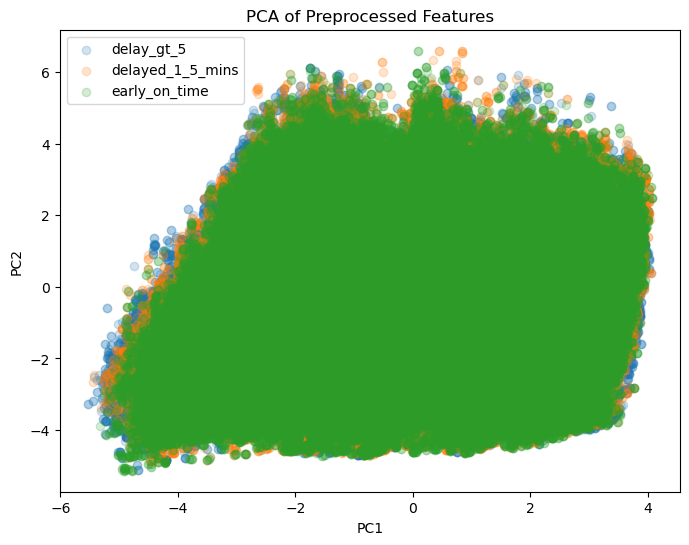

In [37]:


plt.figure(figsize=(8,6))
for label in np.unique(y_train_clf):
    idx = y_train_clf == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.2)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Preprocessed Features')
plt.legend()
plt.show()

--- Step 5: Model Training and Evaluation for Multi-Class Classification ---
Computed Class Weights (based on training data): {'delay_gt_5': 1.390948743082676, 'delayed_1_5_mins': 0.8645733902380605, 'early_on_time': 0.8893423039209347}

--- Training RandomForestClassifier ---

--- RandomForestClassifier Results (Test Set) ---

Classification Report:
                  precision    recall  f1-score   support

   early_on_time       0.31      0.42      0.36    162444
delayed_1_5_mins       0.46      0.45      0.46    268022
      delay_gt_5       0.49      0.39      0.43    238792

        accuracy                           0.42    669258
       macro avg       0.42      0.42      0.41    669258
    weighted avg       0.43      0.42      0.42    669258



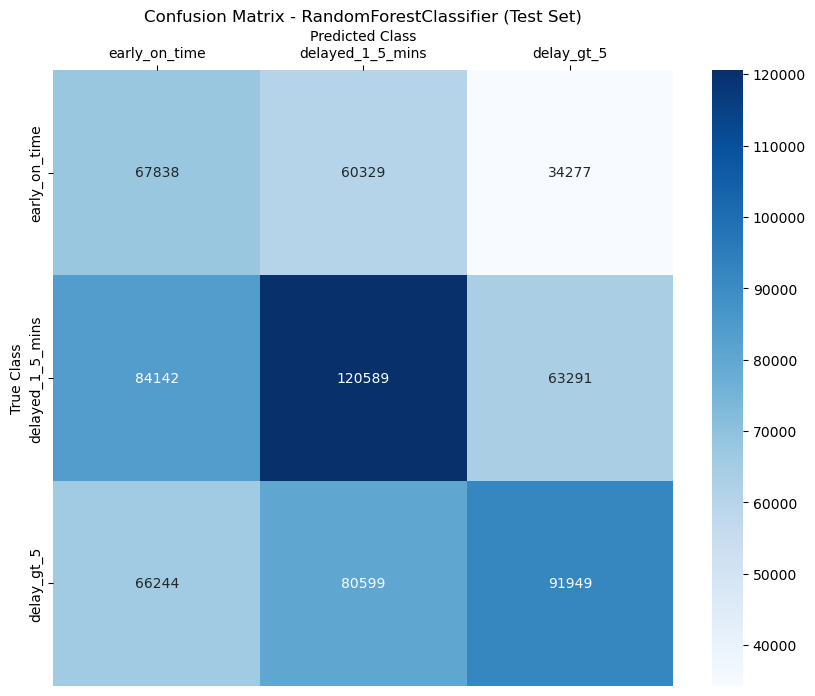

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import class_weight

# --- Step 5: Model Training and Evaluation for Multi-Class Classification ---
print("--- Step 5: Model Training and Evaluation for Multi-Class Classification ---")

# Define the order of classes for consistent metrics and plotting
# class_labels_order = [
#     'early_arrival',
#     'on_time',
#     'delayed_1_5_mins',
#     'delay_gt_5'
# ]

class_labels_order = [
    'early_on_time',
    'delayed_1_5_mins',
    'delay_gt_5'
]

# Calculate class weights for imbalance handling (same as before)
unique_classes = np.unique(y_train_clf)
computed_weights = class_weight.compute_class_weight('balanced', classes=unique_classes, y=y_train_clf)
class_weights_dict = dict(zip(unique_classes, computed_weights))

# # Custome Class Weights Dict
# class_weights_dict = {'delay_gt_5': 2, 'delayed_1_5_mins': 0.8, 'early_on_time': 0.5}


print("Computed Class Weights (based on training data):", class_weights_dict)


# --- Model 1: RandomForestClassifier ---
print("\n--- Training RandomForestClassifier ---")

# Define pipeline for RandomForest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight=class_weights_dict, n_estimators=100, max_depth=10, min_samples_split=5))
    # Using 'balanced' for class_weight is often the easiest start.
    # Added n_estimators, max_depth, min_samples_split explicitly with reasonable values
])

# Train RandomForest
rf_pipeline.fit(X_train_processed, y_train_clf)


# Evaluate RandomForest
y_pred_rf = rf_pipeline.predict(X_test_processed)

print("\n--- RandomForestClassifier Results (Test Set) ---")
print("\nClassification Report:")
print(classification_report(
    y_test_clf, y_pred_rf,
    labels=class_labels_order,         # Ensures correct order
    target_names=class_labels_order    # Ensures correct display
))

# Confusion Matrix for RandomForest
cm_rf = confusion_matrix(
    y_test_clf, y_pred_rf,
    labels=class_labels_order          # Ensures correct order
)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_order, yticklabels=class_labels_order)
plt.title('Confusion Matrix - RandomForestClassifier (Test Set)')
plt.gca().xaxis.set_ticks_position('top')  # Move x-axis ticks to the top
plt.gca().xaxis.set_label_position('top')  # Move x-axis label to the top
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()



Fitting BalancedRandomForestClassifier...

--- BalancedRandomForestClassifier Results (Test Set) ---

Classification Report:
                  precision    recall  f1-score   support

   early_on_time       0.31      0.42      0.36    162444
delayed_1_5_mins       0.46      0.46      0.46    268022
      delay_gt_5       0.49      0.38      0.43    238792

        accuracy                           0.42    669258
       macro avg       0.42      0.42      0.41    669258
    weighted avg       0.43      0.42      0.42    669258



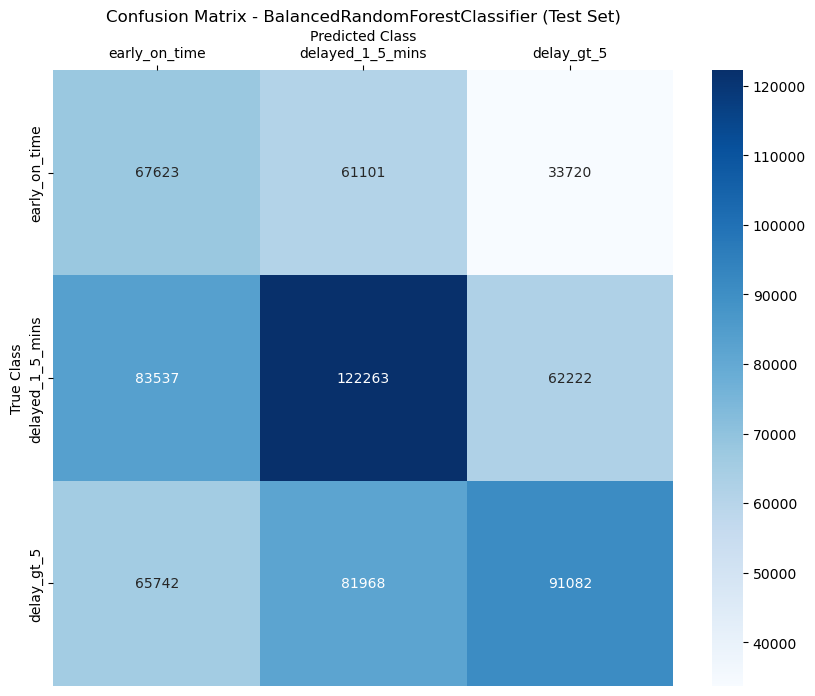

In [39]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Build the pipeline
brf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BalancedRandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        # class_weight=class_weights_dict,  # Optional: can be used in addition to balancing
    ))
])

print("\nFitting BalancedRandomForestClassifier...")
brf_pipeline.fit(X_train_processed, y_train_clf)

# Predict and evaluate
y_pred_brf = brf_pipeline.predict(X_test_processed)

print("\n--- BalancedRandomForestClassifier Results (Test Set) ---")
print("\nClassification Report:")
print(classification_report(
    y_test_clf, y_pred_brf,
    labels=class_labels_order,
    target_names=class_labels_order
))

# Optional: Confusion matrix
cm_brf = confusion_matrix(y_test_clf, y_pred_brf, labels=class_labels_order)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_brf, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_order, yticklabels=class_labels_order)
plt.title('Confusion Matrix - BalancedRandomForestClassifier (Test Set)')
plt.gca().xaxis.set_ticks_position('top')  # Move x-axis ticks to the top
plt.gca().xaxis.set_label_position('top')  # Move x-axis label to the top
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()



--- Training XGBoostClassifier ---

--- Actual y_test_clf Distribution ---
delay_class
delayed_1_5_mins    268022
delay_gt_5          238792
early_on_time       162444
Name: count, dtype: int64

--- XGBoostClassifier Results (Test Set) ---

Classification Report:
                  precision    recall  f1-score   support

   early_on_time       0.31      0.47      0.37    162444
delayed_1_5_mins       0.44      0.56      0.49    268022
      delay_gt_5       0.57      0.19      0.29    238792

        accuracy                           0.41    669258
       macro avg       0.44      0.41      0.39    669258
    weighted avg       0.45      0.41      0.39    669258



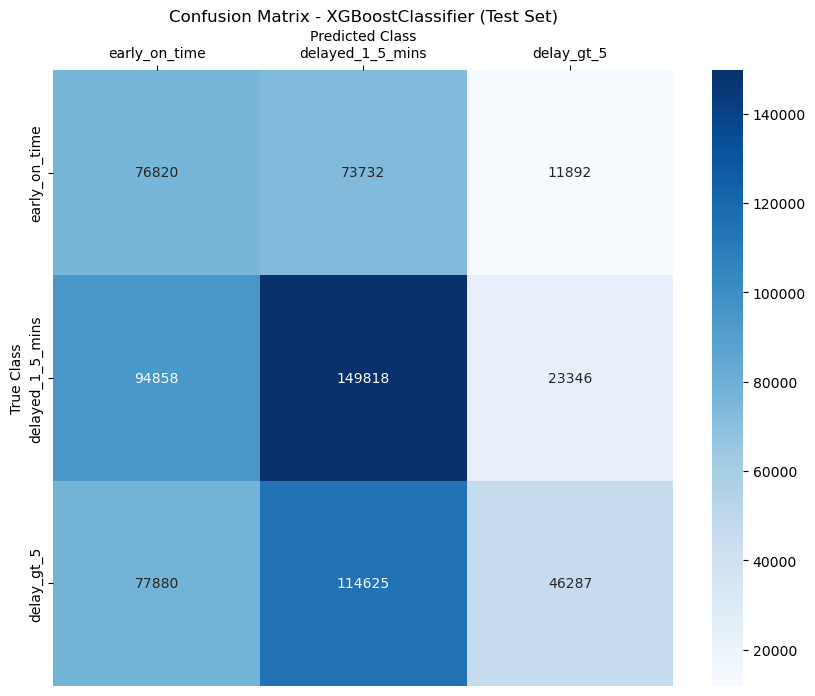

In [40]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# --- Model 2: XGBoostClassifier ---
print("\n--- Training XGBoostClassifier ---")

# # Define the order of classes for consistent metrics and plotting
# class_labels_order = [
#     'early_arrival',
#     'on_time',
#     'delayed_1_5_mins',
#     'delay_gt_5'
# ]

class_labels_order = [
    'early_on_time',
    'delayed_1_5_mins',
    'delay_gt_5'
]

# XGBoost needs integer labels for multi-class classification
# We need to map string labels to integers
label_mapping = {label: i for i, label in enumerate(class_labels_order)}
reverse_label_mapping = {i: label for label, i in label_mapping.items()}

y_train_clf_encoded = y_train_clf.map(label_mapping)
y_test_clf_encoded = y_test_clf.map(label_mapping)

# XGBoost doesn't have a direct 'class_weight' parameter for multi-class like RF
# Instead, you can use 'scale_pos_weight' for binary, or manually
# adjust sample weights if you have a more complex weighting scheme.
# For multi-class, it often implicitly handles imbalance better, or you might
# use 'is_higher_priority' for critical classes.
# For a first pass, let's start without explicit sample weights in the model itself,
# relying on the model's robustness.
# If performance on minority classes is poor, consider `tree_method='hist'` for faster training
# and potentially `enable_categorical=True` if you're passing integer-encoded categories
# directly to XGBoost without OneHotEncoding (which you are not, due to ColumnTransformer).

# Define pipeline for XGBoost
# xgb_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('classifier', XGBClassifier(random_state=42, n_jobs=-1,
#                                  objective='multi:softmax',
#                                  num_class=len(class_labels_order), # Number of unique classes
#                                  eval_metric='mlogloss', # Log loss for multi-class
#                                  n_estimators=100, max_depth=10, learning_rate=0.05)) # Reasonable defaults
# ])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, n_jobs=-1,
                                 objective='multi:softprob',
                                 num_class=len(class_labels_order), # Number of unique classes
                                 eval_metric='mlogloss', # Log loss for multi-class
                                 n_estimators=100, max_depth=10, learning_rate=0.05)) # Reasonable defaults
])

# Train XGBoost
xgb_pipeline.fit(X_train_processed, y_train_clf_encoded) # Fit with encoded labels

# Predict and convert back to original labels for evaluation
y_pred_xgb_encoded = xgb_pipeline.predict(X_test_processed)
y_pred_xgb = pd.Series(y_pred_xgb_encoded).map(reverse_label_mapping).values # Convert back to strings

print("\n--- Actual y_test_clf Distribution ---")
print(y_test_clf.value_counts())


print("\n--- XGBoostClassifier Results (Test Set) ---")
print("\nClassification Report:")

# Classification report
# print(classification_report(
#     y_test_clf_encoded, y_pred_xgb_encoded,
#     labels=[0, 1, 2, 3],
#     target_names=class_labels_order
# ))

# Classification report
print(classification_report(
    y_test_clf_encoded, y_pred_xgb_encoded,
    labels=[0, 1, 2],
    target_names=class_labels_order
))

# # Confusion matrix
# cm_xgb = confusion_matrix(
#     y_test_clf_encoded, y_pred_xgb_encoded,
#     labels=[0, 1, 2, 3]
# )

# Confusion matrix
cm_xgb = confusion_matrix(
    y_test_clf_encoded, y_pred_xgb_encoded,
    labels=[0, 1, 2]
)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_order, yticklabels=class_labels_order)
plt.title('Confusion Matrix - XGBoostClassifier (Test Set)')
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()


                              Feature  Importance
6                   num_std__hour_cos    0.174717
8                  num_std__month_cos    0.108044
10           num_std__day_of_year_cos    0.080061
0            num_std__Air temperature    0.076043
5                   num_std__hour_sin    0.072958
9            num_std__day_of_year_sin    0.072342
13          num_power_std__Snow depth    0.061687
2             num_std__Pressure (msl)    0.050625
7                  num_std__month_sin    0.050353
1      num_std__Dew-point temperature    0.042429
15  num_minmax__Horizontal visibility    0.041662
4         num_std__Wind_Direction_cos    0.038021
14      num_minmax__Relative humidity    0.037972
12          num_power_std__Gust speed    0.032617
3         num_std__Wind_Direction_sin    0.031281
11          num_power_std__Wind speed    0.029188


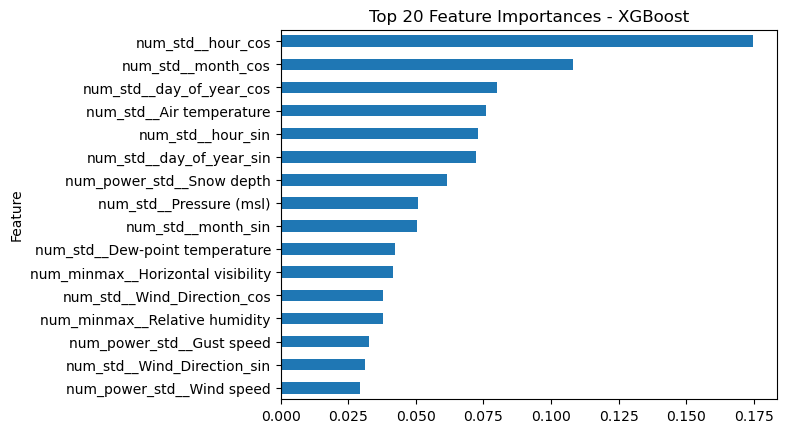

In [41]:
# After fitting your pipeline:
# xgb_pipeline.fit(X_train, y_train)

# 1. Get feature names after preprocessing
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out(X_train_processed.columns)

# 2. Get the fitted XGBoost model
xgb_model = xgb_pipeline.named_steps['classifier']

# 3. Get feature importances
importances = xgb_model.feature_importances_

# 4. Create a DataFrame for better visualization
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 5. Print and plot
print(feat_imp_df)

feat_imp_df.head(20).plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.title('Top 20 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


Fitting Logistic Regression with custom class_weights...


c:\Users\usama\miniconda3\envs\venv_rail_fmi_training\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- Logistic Regression Results (Test Set) ---

Classification Report:
                  precision    recall  f1-score   support

   early_on_time       0.32      0.45      0.37    162444
delayed_1_5_mins       0.45      0.34      0.39    268022
      delay_gt_5       0.46      0.45      0.46    238792

        accuracy                           0.41    669258
       macro avg       0.41      0.42      0.41    669258
    weighted avg       0.42      0.41      0.41    669258



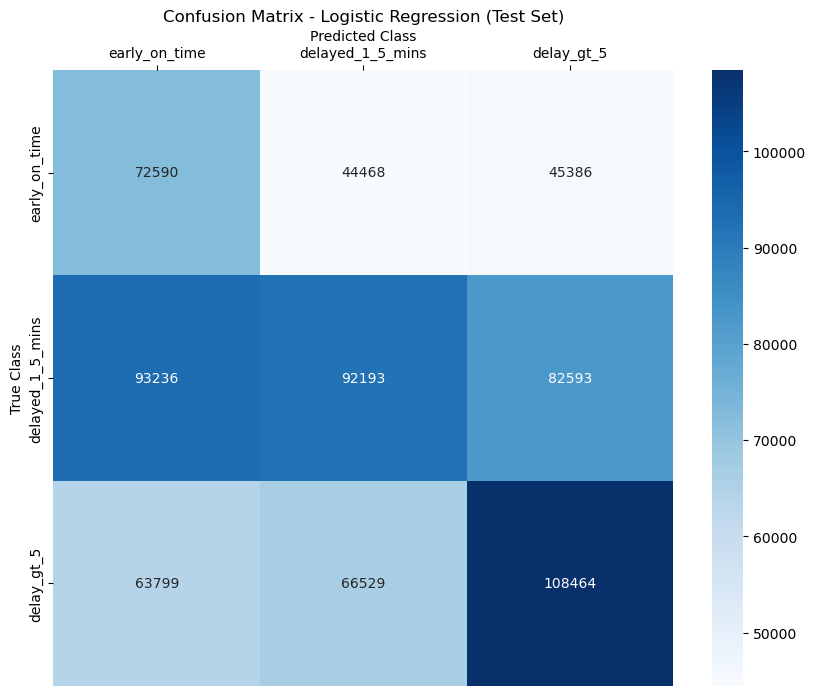

In [42]:
from sklearn.linear_model import LogisticRegression

# Build the pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver='lbfgs',
        multi_class='auto',
        class_weight=class_weights_dict
    ))
])

print("\nFitting Logistic Regression with custom class_weights...")
logreg_pipeline.fit(X_train_processed, y_train_clf)

# Predict and evaluate
y_pred_logreg = logreg_pipeline.predict(X_test_processed)

print("\n--- Logistic Regression Results (Test Set) ---")
print("\nClassification Report:")
print(classification_report(
    y_test_clf, y_pred_logreg,
    labels=class_labels_order,
    target_names=class_labels_order
))

# Confusion matrix
cm_logreg = confusion_matrix(y_test_clf, y_pred_logreg, labels=class_labels_order)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_order, yticklabels=class_labels_order)
plt.title('Confusion Matrix - Logistic Regression (Test Set)')
plt.gca().xaxis.set_ticks_position('top')
plt.gca().xaxis.set_label_position('top')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()